<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/AI/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering

Welcome to the Clustering module. This notebook is designed for both undergraduate and graduate students and is split into four parts:
* **Part 1: Basic Clustering Concepts** — Inertia/WCSS, Dunn Index, Lloyd’s Algorithm.
* **Part 2: Clustering Algorithms & Examples** — K-means, Nearest Neighbor, and DBSCAN examples.
* **Part 3: Code for Basic Clustering** — Implementing k-Means.
* **Part 4: Code for Advanced Clustering & Applications** — Image compression and DBSCAN.

## Table of Contents
* [Part 1: Basic Clustering Concepts](#part_1)
  * [1.1 Inertia / WCSS (Within-Cluster Sum of Squares)](#section_1_1)
  * [1.2 Dunn Index](#section_1_2)
  * [1.3 Lloyd’s Algorithm](#section_1_3)
* [Part 2: Clustering Algorithms & Examples](#part_2)
  * [2.1 K-means Example](#section_2_1)
  * [2.2 Nearest Neighbor Clustering Example](#section_2_2)
  * [2.3 DBSCAN Example](#section_2_3)
* [Part 3: Code for Basic Clustering](#part_3)
  * [3.1 Introducing k-Means](#section_3_1)
  * [3.2 k-Means Algorithm: Expectation–Maximization](#section_3_2)
  * [3.3 k-Means on Digits](#section_3_3)
  * [3.4 Plotting K-Means Epochs](#section_3_4)
* [Part 4: Code for Advanced Clustering & Applications](#part_4)
  * [4.1 k-means for Color Compression](#section_4_1)
  * [4.2 DBSCAN Code](#section_4_2)


<a name="part_1"></a>
# Part 1: Basic Clustering Concepts

Clustering algorithms seek to learn, from the properties of the data, an optimal division or discrete labeling of groups of points.

<a name="section_1_1"></a>
### 1.1 Inertia / WCSS (Within-Cluster Sum of Squares)
Inertia, or the within-cluster sum of squares (WCSS), is a measure of how internally coherent clusters are. It is calculated as the sum of squared distances between each data point and its corresponding cluster centroid.
Lower inertia values are better, indicating that data points are closer to their cluster centers. However, inertia decreases as the number of clusters $k$ increases, so it's often used with the "elbow method" to find the optimal $k$.

$$ WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2 $$
where $C_i$ is the $i$-th cluster and $\mu_i$ is its centroid.

<a name="section_1_2"></a>
### 1.2 Dunn Index
The Dunn Index is a metric for evaluating clustering algorithms. It is designed to identify dense and well-separated clusters.
It is defined as the ratio between the minimal inter-cluster distance to maximal intra-cluster distance.
- **Numerator**: Minimum distance between any two clusters (separation).
- **Denominator**: Maximum distance between any two points within the same cluster (diameter).
A higher Dunn Index indicates better clustering (clusters are compact and well-separated).

$$ Dunn = \frac{\min_{1 \le i < j \le k} d(C_i, C_j)}{\max_{1 \le m \le k} diam(C_m)} $$

<a name="section_1_3"></a>
### 1.3 Lloyd’s Algorithm
Lloyd's algorithm is the standard approach used to solve the k-means clustering problem. It is an iterative expectation-maximization (E-M) algorithm:
1. **Initialization**: Choose $k$ initial cluster centers (seeds) randomly or using a heuristic.
2. **Assignment step (Expectation)**: Assign each data point to the nearest cluster center.
3. **Update step (Maximization)**: Recalculate the centers of the clusters as the mean of all data points assigned to that cluster.
4. **Repeat**: Repeat steps 2 and 3 until the centers no longer change or a maximum number of iterations is reached.


<a name="part_2"></a>
# Part 2: Clustering Algorithms & Examples

> **Link to sample question:** [How to calculate k-means clustering with a numerical example?](https://ask.ghassem.com/656/how-to-calculate-k-means-clustering-with-numerical-example)

<a name="section_2_1"></a>
### 2.1 K-means Example
Use the k-means algorithm and Euclidean distance to cluster the following 8 examples into 3 clusters:
A1=(2,10), A2=(2,5), A3=(8,4), A4=(5,8), A5=(7,5), A6=(6,4), A7=(1,2), A8=(4,9).

**Distance Matrix (Squared Euclidean Distances)**
The distance matrix based on the squared Euclidean distance is given below:

<table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse; text-align: center; margin: 10px 0;">
  <thead>
    <tr>
      <th style="border: 1px solid #ccc; padding: 8px;">Point</th><th style="border: 1px solid #ccc; padding: 8px;">A1</th><th style="border: 1px solid #ccc; padding: 8px;">A2</th><th style="border: 1px solid #ccc; padding: 8px;">A3</th><th style="border: 1px solid #ccc; padding: 8px;">A4</th><th style="border: 1px solid #ccc; padding: 8px;">A5</th><th style="border: 1px solid #ccc; padding: 8px;">A6</th><th style="border: 1px solid #ccc; padding: 8px;">A7</th><th style="border: 1px solid #ccc; padding: 8px;">A8</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A1</b></td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">72</td><td style="border: 1px solid #ccc; padding: 8px;">13</td><td style="border: 1px solid #ccc; padding: 8px;">50</td><td style="border: 1px solid #ccc; padding: 8px;">52</td><td style="border: 1px solid #ccc; padding: 8px;">65</td><td style="border: 1px solid #ccc; padding: 8px;">5</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A2</b></td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">37</td><td style="border: 1px solid #ccc; padding: 8px;">18</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">17</td><td style="border: 1px solid #ccc; padding: 8px;">10</td><td style="border: 1px solid #ccc; padding: 8px;">20</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A3</b></td><td style="border: 1px solid #ccc; padding: 8px;">72</td><td style="border: 1px solid #ccc; padding: 8px;">37</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">2</td><td style="border: 1px solid #ccc; padding: 8px;">4</td><td style="border: 1px solid #ccc; padding: 8px;">53</td><td style="border: 1px solid #ccc; padding: 8px;">41</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A4</b></td><td style="border: 1px solid #ccc; padding: 8px;">13</td><td style="border: 1px solid #ccc; padding: 8px;">18</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">13</td><td style="border: 1px solid #ccc; padding: 8px;">17</td><td style="border: 1px solid #ccc; padding: 8px;">52</td><td style="border: 1px solid #ccc; padding: 8px;">2</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A5</b></td><td style="border: 1px solid #ccc; padding: 8px;">50</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">2</td><td style="border: 1px solid #ccc; padding: 8px;">13</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">2</td><td style="border: 1px solid #ccc; padding: 8px;">45</td><td style="border: 1px solid #ccc; padding: 8px;">25</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A6</b></td><td style="border: 1px solid #ccc; padding: 8px;">52</td><td style="border: 1px solid #ccc; padding: 8px;">17</td><td style="border: 1px solid #ccc; padding: 8px;">4</td><td style="border: 1px solid #ccc; padding: 8px;">17</td><td style="border: 1px solid #ccc; padding: 8px;">2</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">29</td><td style="border: 1px solid #ccc; padding: 8px;">29</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A7</b></td><td style="border: 1px solid #ccc; padding: 8px;">65</td><td style="border: 1px solid #ccc; padding: 8px;">10</td><td style="border: 1px solid #ccc; padding: 8px;">53</td><td style="border: 1px solid #ccc; padding: 8px;">52</td><td style="border: 1px solid #ccc; padding: 8px;">45</td><td style="border: 1px solid #ccc; padding: 8px;">29</td><td style="border: 1px solid #ccc; padding: 8px;">0</td><td style="border: 1px solid #ccc; padding: 8px;">58</td></tr>
    <tr><td style="border: 1px solid #ccc; padding: 8px;"><b>A8</b></td><td style="border: 1px solid #ccc; padding: 8px;">5</td><td style="border: 1px solid #ccc; padding: 8px;">20</td><td style="border: 1px solid #ccc; padding: 8px;">41</td><td style="border: 1px solid #ccc; padding: 8px;">2</td><td style="border: 1px solid #ccc; padding: 8px;">25</td><td style="border: 1px solid #ccc; padding: 8px;">29</td><td style="border: 1px solid #ccc; padding: 8px;">58</td><td style="border: 1px solid #ccc; padding: 8px;">0</td></tr>
  </tbody>
</table>

Suppose that the initial seeds are A1, A4, and A7.
- Seed1 = A1 = (2,10)
- Seed2 = A4 = (5,8)
- Seed3 = A7 = (1,2)

**Epoch 1:**
- A1: distance to seed1 is 0. A1 belongs to Cluster 1.
- A2: distances to seeds (5, 4.24, 3.16). Smallest is to seed3. A2 belongs to Cluster 3.
- A3: distances to seeds (8.48, 5, 7.28). Smallest is to seed2. A3 belongs to Cluster 2.
- A4: distance to seed2 is 0. A4 belongs to Cluster 2.
- A5: distances to seeds (7.07, 3.60, 6.70). Smallest is to seed2. A5 belongs to Cluster 2.
- A6: distances to seeds (7.21, 4.12, 5.38). Smallest is to seed2. A6 belongs to Cluster 2.
- A7: distance to seed3 is 0. A7 belongs to Cluster 3.
- A8: distances to seeds (2.23, 1.41, 7.6). Smallest is to seed2. A8 belongs to Cluster 2.

**End of Epoch 1:**
- K1: {A1}
- K2: {A3, A4, A5, A6, A8}
- K3: {A2, A7}
- Centers: C1=(2,10), C2=(6,6), C3=(1.5, 3.5)

**Epoch 2:**
Using the new centers: C1=(2,10), C2=(6,6), C3=(1.5, 3.5)
- After assigning points to the nearest centers, A8 moves to Cluster 1.
- K1: {A1, A8}
- K2: {A3, A4, A5, A6}
- K3: {A2, A7}
- Centers: C1=(3, 9.5), C2=(6.5, 5.25), C3=(1.5, 3.5)

**Epoch 3 (Convergence):**
Using the new centers: C1=(3, 9.5), C2=(6.5, 5.25), C3=(1.5, 3.5)
- After assigning points, A4 moves to Cluster 1.
- K1: {A1, A4, A8}
- K2: {A3, A5, A6}
- K3: {A2, A7}
- Centers: C1=(3.66, 9), C2=(7, 4.33), C3=(1.5, 3.5)

*(Note: The Python code to generate the 2D visual representation of these epochs can be found in [Section 3.4](#section_3_4).)*

<a name="section_2_2"></a>
### 2.2 Nearest Neighbor Clustering Example
Use the Nearest Neighbor clustering algorithm and Euclidean distance to cluster the examples from the previous exercise:
A1=(2,10), A2=(2,5), A3=(8,4), A4=(5,8), A5=(7,5), A6=(6,4), A7=(1,2), A8=(4,9).

Suppose that the threshold $t$ is 4.

**Step-by-step Execution:**
- **A1**: Placed in a cluster by itself, so we have K1={A1}.
- **A2**: We compare the distance to K1.
  - $d(A1,A2)= 5 > t \implies$ Placed in a new cluster K2={A2}
- **A3**: We compare the distances from A3 to A1 and A2.
  - A3 is closer to A2 and $d(A3,A2)= 6.08 > t \implies$ Placed in a new cluster K3={A3}
- **A4**: We compare the distances from A4 to A1, A2 and A3.
  - A1 is the closest object and $d(A4,A1)= 3.6 < t \implies$ K1={A1, A4}
- **A5**: We compare the distances from A5 to A1, A2, A3 and A4.
  - A3 is the closest object and $d(A5,A3)= 1.41 < t \implies$ K3={A3, A5}
- **A6**: We compare the distances from A6 to A1, A2, A3, A4 and A5.
  - A3 is the closest object and $d(A6,A3)= 2 < t \implies$ K3={A3, A5, A6}
- **A7**: We compare the distances from A7 to A1, A2, A3, A4, A5, and A6.
  - A2 is the closest object and $d(A7,A2)= 3.16 < t \implies$ K2={A2, A7}
- **A8**: We compare the distances from A8 to A1, A2, A3, A4, A5, A6 and A7.
  - A4 is the closest object and $d(A8,A4)= 1.41 < t \implies$ K1={A1, A4, A8}

**Final Result:**
- K1={A1, A4, A8}
- K2={A2, A7}
- K3={A3, A5, A6}

*(This yields the exact same clusters as K-means!)*

<a name="section_2_3"></a>
### 2.3 DBSCAN Example
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together dense clusters of points and separates sparse noise points. It works by defining a cluster as a dense region of points separated from other dense regions by areas of low point density.

The algorithm requires two parameters: epsilon ($\epsilon$) and the minimum number of points (`minPts` or `min_samples`) required to form a dense region. The algorithm starts from an arbitrary point and retrieves all points within a distance of $\epsilon$. If a point has at least `minPts` within a distance of $\epsilon$, a cluster is formed. The algorithm then proceeds to expand the cluster by checking all points within the $\epsilon$ distance of the newly added points. Points that cannot be reached by any cluster are considered as noise.

**DBSCAN Example:**
Let's consider the following points in 2D space: A1=(2,10), A2=(2,5), A3=(8,4), A4=(5,8), A5=(7,5), A6=(6,4), A7=(1,2), A8=(4,9)

The DBSCAN algorithm groups the points into clusters based on two parameters: `eps` (Epsilon) and `min_samples`. The `eps` parameter determines the maximum distance between two points in the same cluster, while the `min_samples` parameter determines the minimum number of points required to form a dense region.

**What if `eps=2` and `min_samples=2`?**

If we set `Epsilon=2` and `min_samples=2`, the algorithm will work as follows:

$$
\begin{aligned}
& \mathrm{N}_2(\mathrm{~A} 1)=\{\} ; \mathrm{N}_2(\mathrm{~A} 2)=\{\} ; \mathrm{N}_2(\mathrm{~A} 3)=\{\mathrm{A} 5, \mathrm{~A} 6\} ; \mathrm{N}_2(\mathrm{~A} 4)=\{\mathrm{A} 8\} ; \mathrm{N}_2(\mathrm{~A} 5)=\{\mathrm{A} 3, \mathrm{~A} 6\} ; \\
& \mathrm{N}_2(\mathrm{~A} 6)=\{\mathrm{A} 3, \mathrm{~A} 5\} ; \mathrm{N}_2(\mathrm{~A} 7)=\{\} ; \mathrm{N}_2(\mathrm{~A} 8)=\{\mathrm{A} 4\}
\end{aligned}
$$
    
So A1, A2, and A7 are outliers (noise), while we have two clusters C1={A4, A8} and C2={A3, A5, A6}
    
*   Cluster 1: {A4, A8}
*   Cluster 2: {A3, A5, A6}
*   Noise points: {A1, A2, A7}

**What if Epsilon is increased to $\sqrt{10}$?**

A1 would join the cluster C1 and A2 would joint with A7 to form cluster C3={A2, A7}

*   Cluster 1: {A1, A4, A8}
*   Cluster 2: {A3, A5, A6}
*   Cluster 3: {A2, A7}
*   Noise points: {}


<a name="part_3"></a>
# Part 3: Code for Basic Clustering

In this section, we will implement and visualize k-Means clustering using Scikit-Learn.

<a name="section_3_1"></a>
### 3.1 Introducing k-Means
The *k*-means algorithm searches for a pre-determined number of clusters within an unlabeled multidimensional dataset. It accomplishes this using a simple conception of what the optimal clustering looks like.



In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
import pandas as pd

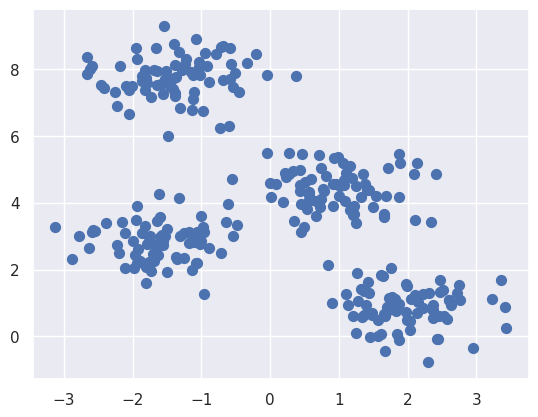

In [19]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.6, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

By eye, it is relatively easy to pick out the four clusters. The *k*-means algorithm does this automatically, and in Scikit-Learn uses the typical estimator API:


In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

Let's visualize the results by plotting the data colored by these labels. We will also plot the cluster centers as determined by the *k*-means estimator:


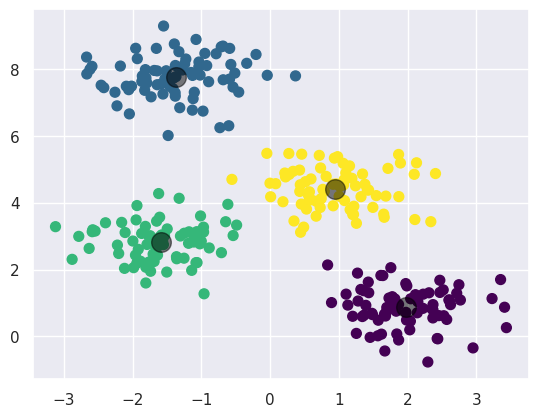

In [21]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

<a name="section_3_2"></a>
### 3.2 k-Means Algorithm: Expectation–Maximization
Expectation–maximization (E–M) is a powerful algorithm that comes up in a variety of contexts within data science. *k*-means is a particularly simple and easy-to-understand application of the algorithm.

The *k*-Means algorithm is simple enough that we can write it in a few lines of code. The following is a very basic implementation:


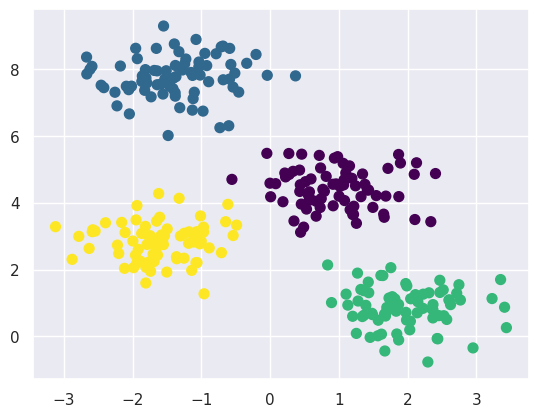

In [22]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

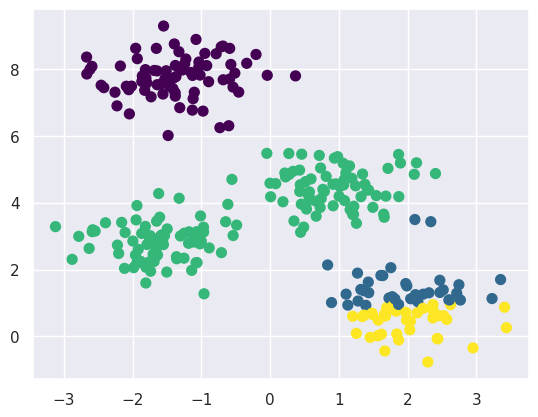

In [23]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

<a name="section_3_3"></a>
### 3.3 k-Means on Digits
To start, let's take a look at applying *k*-means on the simple digits data. Here we will attempt to use *k*-means to try to identify similar digits *without using the original label information*.


In [24]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

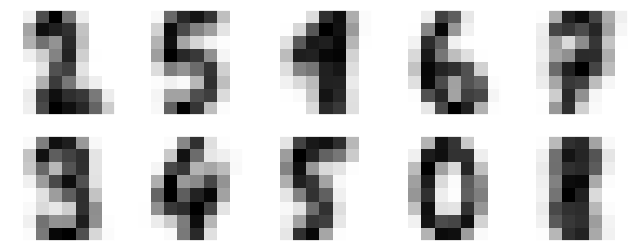

In [25]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10, random_state=0, n_init='auto')
kmeans.fit(digits.data)

fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

The result is 10 clusters in 64 dimensions. Notice that the cluster centers themselves are 64-dimensional points, and can themselves be interpreted as the "typical" digit within the cluster. Let's see what these cluster centers look like:


In [26]:
#pd.DataFrame(digits.target)

<a name="section_3_4"></a>
### 3.4 Plotting K-Means Epochs
Below is the code used to generate the 2D representations of the K-means epochs discussed in [Section 2.1](#section_2_1).


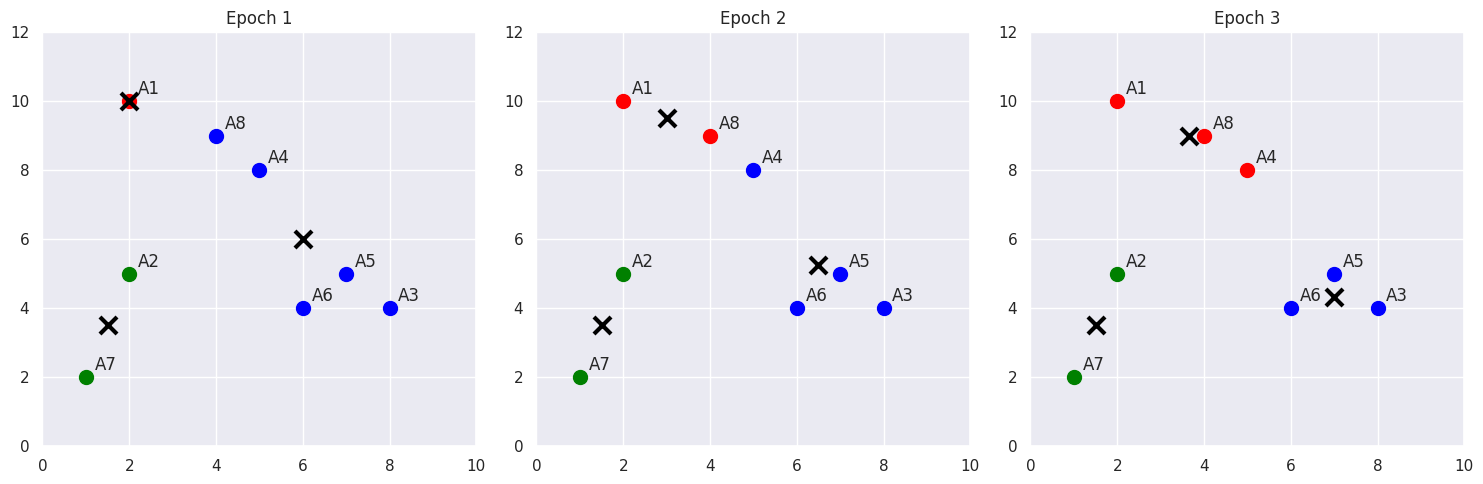

In [27]:
import matplotlib.pyplot as plt
import numpy as np

points = {"A1":(2,10), "A2":(2,5), "A3":(8,4), "A4":(5,8), "A5":(7,5), "A6":(6,4), "A7":(1,2), "A8":(4,9)}
epochs = [
    {
        "title": "Epoch 1",
        "clusters": {"K1":["A1"], "K2":["A3","A4","A5","A6","A8"], "K3":["A2","A7"]},
        "centers": [(2,10), (6,6), (1.5,3.5)]
    },
    {
        "title": "Epoch 2",
        "clusters": {"K1":["A1","A8"], "K2":["A3","A4","A5","A6"], "K3":["A2","A7"]},
        "centers": [(3,9.5), (6.5,5.25), (1.5,3.5)]
    },
    {
        "title": "Epoch 3",
        "clusters": {"K1":["A1","A4","A8"], "K2":["A3","A5","A6"], "K3":["A2","A7"]},
        "centers": [(3.66, 9), (7, 4.33), (1.5, 3.5)]
    }
]

colors = {"K1": "red", "K2": "blue", "K3": "green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, epoch in enumerate(epochs):
    ax = axes[i]
    ax.set_title(epoch["title"])
    for cluster_name, p_names in epoch["clusters"].items():
        color = colors[cluster_name]
        for p in p_names:
            x, y = points[p]
            ax.scatter(x, y, color=color, s=100)
            ax.annotate(p, (x+0.2, y+0.2))
    for cx, cy in epoch["centers"]:
        ax.scatter(cx, cy, color="black", marker="x", s=150, linewidths=3)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.grid(True)

plt.tight_layout()
plt.show()


<a name="part_4"></a>
# Part 4: Code for Advanced Clustering & Applications

<a name="section_4_1"></a>
### 4.1 k-means for Color Compression
One interesting application of clustering is in color compression within images. For example, imagine you have an image with millions of colors. In most images, a large number of the colors will be unused, and many of the pixels in the image will have similar or even identical colors.



In [28]:
from sklearn.decomposition import PCA
from scipy.stats import mode
from sklearn.metrics import accuracy_score

pca = PCA(n_components=5)
pca_result = pca.fit_transform(digits.data)

# Compute the clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(pca_result)

# Permute the labels
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# Compute the accuracy
accuracy_score(digits.target, labels)

0.7178631051752922

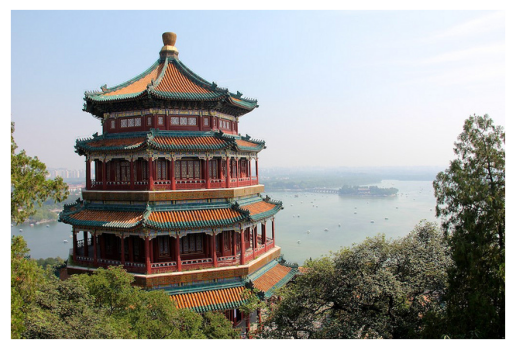

In [29]:
# Note: this requires the ``pillow`` package to be installed
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china);

In [30]:
china.shape

(427, 640, 3)

In [31]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

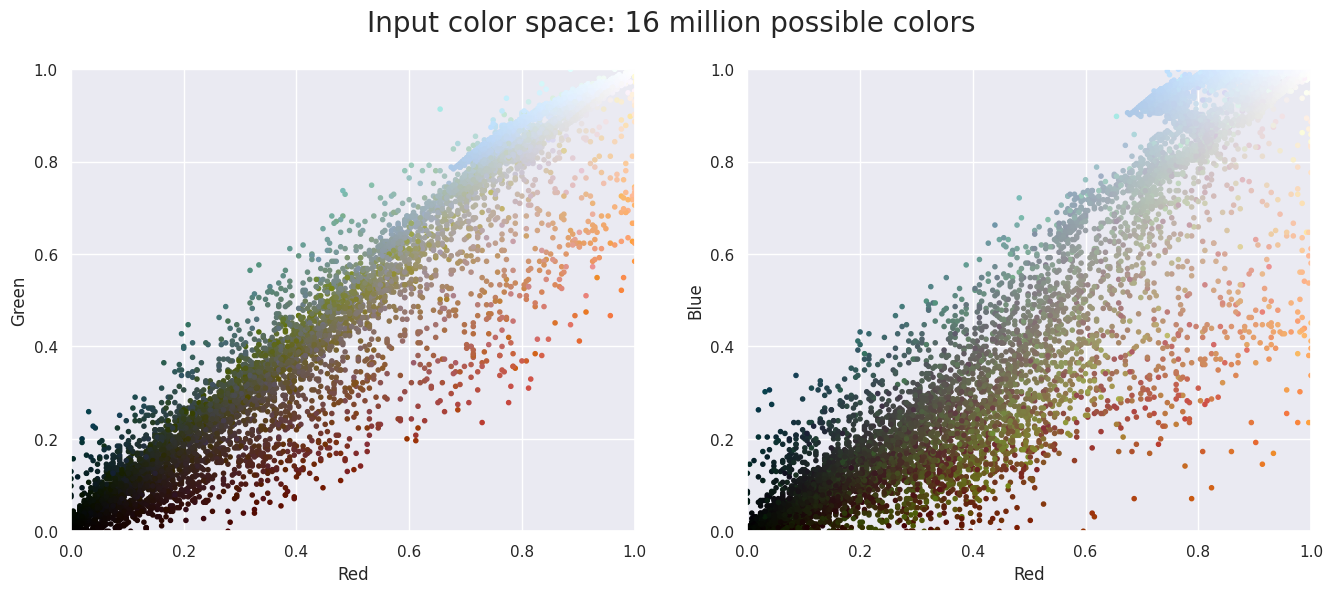

In [32]:
data = china.reshape(-1, 3) / 255.0
plot_pixels(data, title='Input color space: 16 million possible colors')

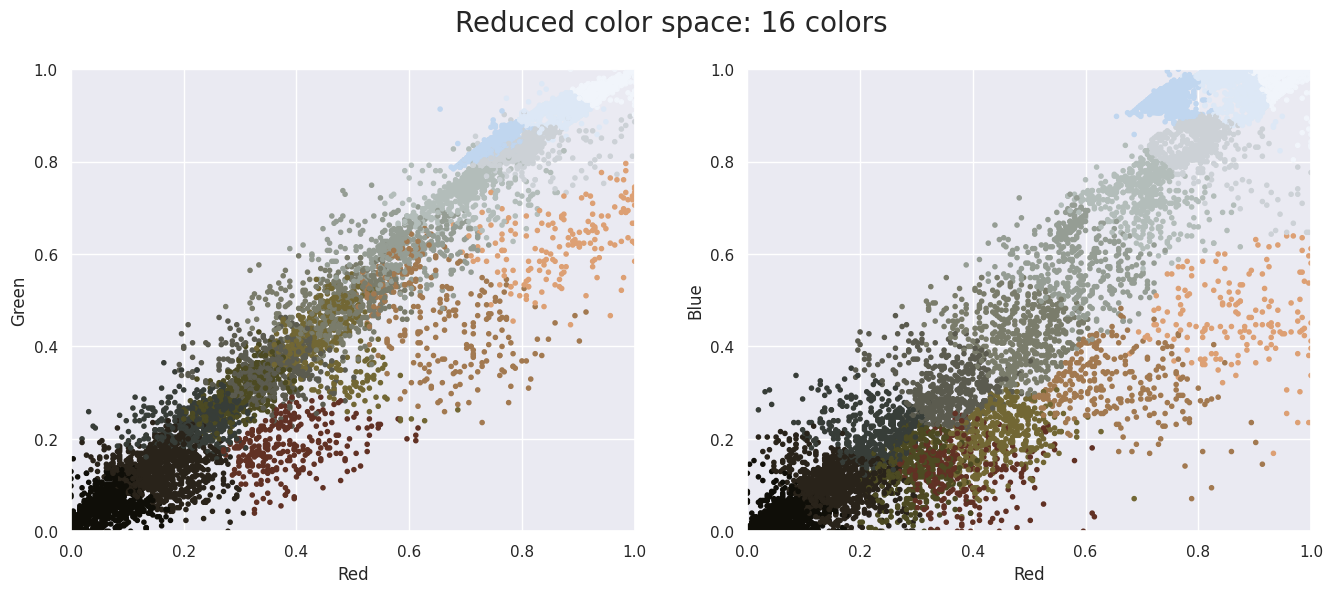

In [33]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 16 colors")

<a name="section_4_2"></a>
### 4.2 DBSCAN Code
Let's see DBSCAN in action on the 2D points from our example.


In [34]:
import numpy as np
from sklearn.cluster import DBSCAN

# Define the dataset
X = np.array([[2, 10], [2, 5], [8, 4], [5, 8], [7, 5], [6, 4], [1, 2], [4, 9], [5, 2], [6, 3]])


print("-----------------------------------------")
print("Apply DBSCAN for (eps=2, min_samples=2)")
print("-----------------------------------------")

# Apply DBSCAN for (eps=2, min_samples=2)
db = DBSCAN(eps=2, min_samples=2).fit(X)
labels = db.labels_


# Print the clusters and the noise points

print("Cluster labels:", labels)

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters_)

for i in set(labels):
    print("Cluster", i+1, ":", X[labels == i])

print("Noise points:", X[labels == -1])

print("-----------------------------------------------")
print("Apply DBSCAN for (eps=sqrt(10), min_samples=2)")
print("-----------------------------------------------")

# Apply DBSCAN for (eps=2, min_samples=2)
db = DBSCAN(eps=np.sqrt(10), min_samples=2).fit(X)
labels = db.labels_

# Print the clusters and the noise points

print("Cluster labels:", labels)

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters_)

for i in set(labels):
    print("Cluster", i+1, ":", X[labels == i])

print("Noise points:", X[labels == -1])

-----------------------------------------
Apply DBSCAN for (eps=2, min_samples=2)
-----------------------------------------
Cluster labels: [-1 -1  0  1  0  0 -1  1  0  0]
Number of clusters: 2
Cluster 1 : [[8 4]
 [7 5]
 [6 4]
 [5 2]
 [6 3]]
Cluster 2 : [[5 8]
 [4 9]]
Cluster 0 : [[ 2 10]
 [ 2  5]
 [ 1  2]]
Noise points: [[ 2 10]
 [ 2  5]
 [ 1  2]]
-----------------------------------------------
Apply DBSCAN for (eps=sqrt(10), min_samples=2)
-----------------------------------------------
Cluster labels: [0 1 2 0 2 2 1 0 2 2]
Number of clusters: 3
Cluster 1 : [[ 2 10]
 [ 5  8]
 [ 4  9]]
Cluster 2 : [[2 5]
 [1 2]]
Cluster 3 : [[8 4]
 [7 5]
 [6 4]
 [5 2]
 [6 3]]
Noise points: []


© 2026 Ghassem Tofighi. All rights reserved. Unauthorized reuse or distribution is prohibited.
